# Specifying the random forest model

> **Quick info:** <br>
>
> This notebook demonstrates how to use the three output files (`classifier.pkl`, `cls_report.pkl`, `confusion_matrix.npy`) produced by running `train_classifier.py` from the command line. These files allow for loading the model and inspecting its performance evaluated on a hold-out set.

In [1]:
import joblib
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

First, let's load the model: 

In [2]:
model = joblib.load("../models/classifier.pkl")

Now, we are going to print the best hyperparameters performed via a random grid search
that draws parameter combinations from the following grid.

In [3]:
# display the pre-defined parameter grid:
model.param_distributions

{'vect__ngram_range': ((1, 1), (1, 2)),
 'vect__max_df': (0.5, 0.75, 1.0),
 'vect__max_features': (None, 5000, 10000),
 'tfidf__use_idf': (True, False),
 'clf__n_estimators': [50, 100, 200],
 'clf__min_samples_split': [3, 4, 5]}

In [4]:
# display the best performing combination of hyperparameters:
model.best_params_

{'vect__ngram_range': (1, 2),
 'vect__max_features': 10000,
 'vect__max_df': 0.75,
 'tfidf__use_idf': False,
 'clf__n_estimators': 200,
 'clf__min_samples_split': 5}

The performance of the model was evaluated on hold-out set that accounts for 20% of the (cleaned) data.<br>
Below you see the output of [Scikit-learn's classification report](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html). This information is also written in the
terminal when running `train_classifier.py`.

```

                        precision    recall  f1-score   support

               request       0.93      0.23      0.37       920
                 offer       0.00      0.00      0.00        25
           aid_related       0.56      1.00      0.72      2207
          medical_help       0.28      0.14      0.18       445
      medical_products       0.37      0.19      0.25       277
     search_and_rescue       0.19      0.05      0.07       153
              security       1.00      0.01      0.02       104
              military       0.00      0.00      0.00       181
                 water       0.63      0.57      0.60       341
                  food       0.62      0.73      0.67       577
               shelter       0.54      0.49      0.51       461
              clothing       0.42      0.14      0.21        80
                 money       1.00      0.02      0.03       121
        missing_people       0.15      0.03      0.04        80
              refugees       0.50      0.01      0.02       174
                 death       0.53      0.19      0.28       250
             other_aid       0.67      0.00      0.01       706
infrastructure_related       0.19      0.13      0.15       324
             transport       0.20      0.07      0.10       235
             buildings       0.40      0.17      0.24       260
           electricity       0.16      0.04      0.06        80
                 tools       0.00      0.00      0.00        34
             hospitals       0.00      0.00      0.00        57
                 shops       0.00      0.00      0.00        26
           aid_centers       0.00      0.00      0.00        60
  other_infrastructure       1.00      0.01      0.02       220
       weather_related       0.40      0.97      0.57      1427
                floods       0.76      0.03      0.06       418
                 storm       0.90      0.02      0.04       486
                  fire       0.00      0.00      0.00        56
            earthquake       0.71      0.61      0.66       449
                  cold       0.00      0.00      0.00       108
         other_weather       0.00      0.00      0.00       274
         direct_report       0.92      0.19      0.32      1016

             micro avg       0.51      0.43      0.47     12632
             macro avg       0.41      0.18      0.18     12632
          weighted avg       0.57      0.43      0.37     12632
           samples avg       0.49      0.33      0.37     12632
```

We put some emphasis on obtaining a model that shows high recall, which means that relatively few help messages
remain unnoticed. <br>
Still, the model's precision is not ideal, especially for categories with few positive examples.

You can also generate this classification report from the output file `cls_report.cls` like so:

In [5]:
with open('../models/cls_report.pkl', 'rb') as handle:
    loaded_report = pickle.load(handle)
    
df = pd.DataFrame.from_dict(loaded_report)
df.T

,precision,recall,f1-score,support
request,0.926407,0.232609,0.371851,920.0
offer,0.000000,0.000000,0.000000,25.0
aid_related,0.557522,0.999094,0.715677,2207.0
medical_help,0.279817,0.137079,0.184012,445.0
medical_products,0.368794,0.187726,0.248804,277.0
search_and_rescue,0.194444,0.045752,0.074074,153.0
security,1.000000,0.009615,0.019048,104.0
military,0.000000,0.000000,0.000000,181.0
water,0.625806,0.568915,0.596006,341.0
food,0.616959,0.731369,0.669310,577.0


After loading `confusion_matrix.npy`, we can also examine the confusion matrix of each category.

In [6]:
from sklearn.metrics import plot_confusion_matrix
from sklearn.metrics._classification import confusion_matrix
from sklearn.metrics._plot.confusion_matrix import ConfusionMatrixDisplay

In [7]:
# load the confusion matrices:
categories = [cat.replace('_', ' ') for cat in df.columns if not 'avg' in cat]

# clean the category labels
confusion_matrices = np.load('../models/confusion_matrix.npy')

Text(0.5, 1.0, 'request')

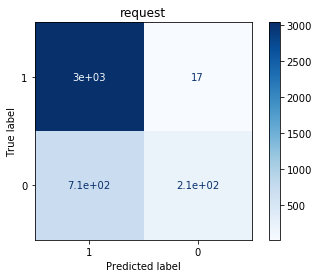

In [8]:
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrices[0],
                              display_labels=None)
disp.display_labels = [1, 0]
disp.plot(cmap=plt.cm.Blues)
disp.ax_.set_title(categories[0])

In [9]:
# quickly print all confusion matrices:
for label, matrix in zip(categories, confusion_matrices):
    print(f'{label}\n{matrix}\n')

request
[[3038   17]
 [ 706  214]]

offer
[[3950    0]
 [  25    0]]

aid related
[[  18 1750]
 [   2 2205]]

medical help
[[3373  157]
 [ 384   61]]

medical products
[[3609   89]
 [ 225   52]]

search and rescue
[[3793   29]
 [ 146    7]]

security
[[3871    0]
 [ 103    1]]

military
[[3794    0]
 [ 181    0]]

water
[[3518  116]
 [ 147  194]]

food
[[3136  262]
 [ 155  422]]

shelter
[[3320  194]
 [ 234  227]]

clothing
[[3880   15]
 [  69   11]]

money
[[3854    0]
 [ 119    2]]

missing people
[[3884   11]
 [  78    2]]

refugees
[[3799    2]
 [ 172    2]]

death
[[3682   43]
 [ 202   48]]

other aid
[[3268    1]
 [ 704    2]]

infrastructure related
[[3471  180]
 [ 283   41]]

transport
[[3676   64]
 [ 219   16]]

buildings
[[3648   67]
 [ 215   45]]

electricity
[[3879   16]
 [  77    3]]

tools
[[3936    5]
 [  34    0]]

hospitals
[[3914    4]
 [  57    0]]

shops
[[3942    7]
 [  26    0]]

aid centers
[[3911    4]
 [  60    0]]

other infrastructure
[[3755    0]
 [ 218    2